In [12]:
#Titanic dataset analysis using pandas and matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
def load_data():
    return pd.read_csv("train_and_test2.csv")
def find_missing_values(df):
    return df.isnull().sum()
#dignose the data
def diagnose_data(df):
    print("Data types:\n", df.dtypes)
    print("\nSummary statistics:\n", df.describe())
    print("\nFirst 5 rows:\n", df.head())
def clean_data(df):
    if 'Age' in df.columns:
        df['Age'] = df['Age'].fillna(df['Age'].median())
    if 'Embarked' in df.columns:
        df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
    if 'Cabin' in df.columns:
        df['Cabin'] = df['Cabin'].fillna("Unknown")
    return df
#merge train and test datasets
def merge_datasets(train_df, test_df):
    return pd.concat([train_df, test_df], ignore_index=True)
#surival rate by gender
def survival_rate_by_gender(df):
    return df.groupby('Sex')['2urvived'].mean()
#survival rate by age group
def survival_rate_by_age_group(df):
    bins = [0, 12, 18, 35, 60, 100]
    labels = ['Child', 'Teen', 'Adult', 'Middle-aged', 'Senior']
    df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)
    return df.groupby('AgeGroup')['2urvived'].mean()
#fare analysis
def fare_analysis(df):
    return df.groupby('Pclass')['Fare'].mean()
df = load_data()
df = clean_data(df)

print(survival_rate_by_gender(df))
print(survival_rate_by_age_group(df))
print(fare_analysis(df))


Sex
0    0.1293
1    0.5000
Name: 2urvived, dtype: float64
AgeGroup
Child          0.425532
Teen           0.303030
Adult          0.238035
Middle-aged    0.269896
Senior         0.151515
Name: 2urvived, dtype: float64
Pclass
1    87.508992
2    21.179196
3    13.304513
Name: Fare, dtype: float64


In [16]:
#survival rate
def survival_rate(df):
    return df['2urvived'].mean()
print("Overall survival rate:", survival_rate(df))
#age statistics
def age_statistics(df):
    return df['Age'].describe()
print("Age statistics:\n", age_statistics(df))
def add_family_size_numpy(df):
  df['FamilySize'] = np.add(df['SibSp'], df['Parch'])
  return df


Overall survival rate: 0.2612681436210848
Age statistics:
 count    1309.000000
mean       29.503186
std        12.905241
min         0.170000
25%        22.000000
50%        28.000000
75%        35.000000
max        80.000000
Name: Age, dtype: float64


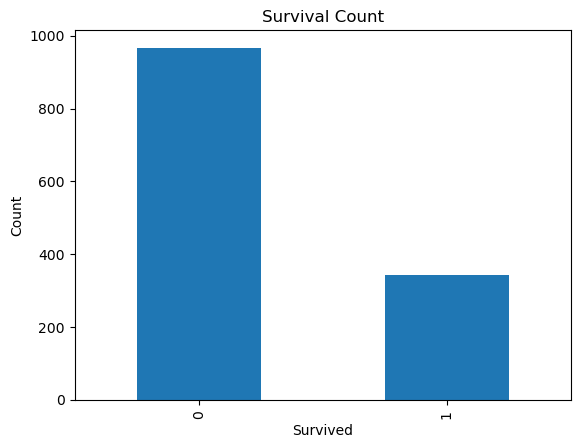

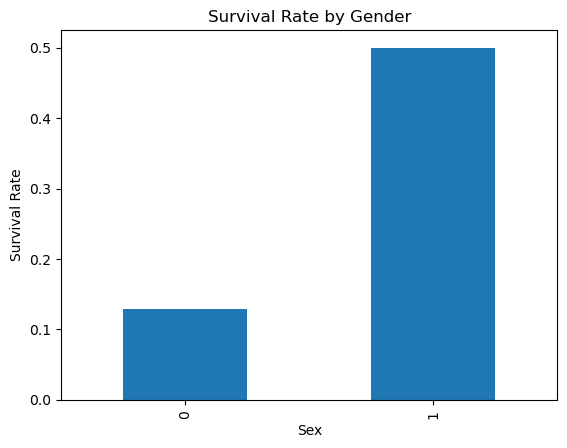

In [20]:
#plot survival count
def plot_survival_count(df):
    df['2urvived'].value_counts().plot(kind='bar')
    plt.xlabel('Survived')
    plt.ylabel('Count')
    plt.title('Survival Count')
    plt.show()
#plot survival rate by gender
def plot_survival_rate_by_gender(df):
    survival_rate = df.groupby('Sex')['2urvived'].mean()
    survival_rate.plot(kind='bar')
    plt.xlabel('Sex')
    plt.ylabel('Survival Rate')
    plt.title('Survival Rate by Gender')
    plt.show()
plot_survival_count(df)
plot_survival_rate_by_gender(df)

